In [1]:
import h5py
import os
os.getcwd()


'/scratch/ty296'

In [ ]:
# Save plot data to CSV
output_filename = 'variance_vs_p_data.csv'
df_to_save = df[['variance', 'standard_error_of_variance']].copy()
df_to_save.to_csv(output_filename)
print(f"Data saved to {output_filename}")


In [2]:
import os

# List all files in the directory "hdf5_data/p_ctrl0.4_haining/"
dir_path = "hdf5_data/p_ctrl0.4_haining/"
files = os.listdir(dir_path)
files_full_path = [os.path.join(dir_path, f) for f in files]


In [3]:
files

['MPS_L24_pctrl0.400_pproj0.520_s529.h5',
 'MPS_L16_pctrl0.400_pproj0.796_s416.h5',
 'MPS_L16_pctrl0.400_pproj0.602_s1909.h5',
 'MPS_L24_pctrl0.400_pproj0.765_s856.h5',
 'MPS_L24_pctrl0.400_pproj0.633_s1955.h5',
 'MPS_L16_pctrl0.400_pproj0.796_s698.h5',
 'MPS_L16_pctrl0.400_pproj0.531_s415.h5',
 'MPS_L20_pctrl0.400_pproj0.684_s529.h5',
 'MPS_L24_pctrl0.400_pproj0.714_s29.h5',
 'MPS_L24_pctrl0.400_pproj0.857_s934.h5',
 'MPS_L20_pctrl0.400_pproj0.551_s1620.h5',
 'MPS_L16_pctrl0.400_pproj0.888_s308.h5',
 'MPS_L20_pctrl0.400_pproj0.745_s1757.h5',
 'MPS_L20_pctrl0.400_pproj0.980_s1973.h5',
 'MPS_L12_pctrl0.400_pproj0.786_s374.h5',
 'MPS_L20_pctrl0.400_pproj0.520_s453.h5',
 'MPS_L24_pctrl0.400_pproj0.724_s1620.h5',
 'MPS_L20_pctrl0.400_pproj0.867_s859.h5',
 'MPS_L24_pctrl0.400_pproj0.724_s1051.h5',
 'MPS_L16_pctrl0.400_pproj0.551_s417.h5',
 'MPS_L16_pctrl0.400_pproj0.888_s518.h5',
 'MPS_L12_pctrl0.400_pproj0.571_s1086.h5',
 'MPS_L20_pctrl0.400_pproj0.612_s1590.h5',
 'MPS_L12_pctrl0.400_pproj

In [4]:
import datetime
import tqdm


In [9]:

combined_sv_filename = f"hdf5_data_combined/sv_combined_p_ctrl0.4_{datetime.datetime.now().strftime('%Y-%m-%d')}.h5"
print(combined_sv_filename)

# with h5py.File(combined_sv_filename, 'w') as f_target:
#     # No need to open files! Just create links directly
#     for i, filename in enumerate(tqdm.tqdm(files_full_path)):
#         ds_name = files[i]
#         # Create external link instead of copying
#         f_target[ds_name] = h5py.ExternalLink(filename, 'sv_arr')


hdf5_data_combined/sv_combined_p_ctrl0.4_2025-11-08.h5


In [10]:
import h5py
import tqdm
new_combined_sv_filename = f"hdf5_data_combined/sv_combined_p_ctrl0.4_{datetime.datetime.now().strftime('%Y-%m-%d')}_copy.h5"
print(new_combined_sv_filename)

hdf5_data_combined/sv_combined_p_ctrl0.4_2025-11-08_copy.h5


In [11]:
# with h5py.File(new_combined_sv_filename, 'w') as f_dest:
#     with h5py.File(combined_sv_filename, 'r') as f_source:
#         for key in tqdm.tqdm(f_source.keys()):
#             # This resolves the external links and copies actual data
#             f_dest.copy(f_source[key], key, expand_external=True)

In [ ]:
import numpy as np
from collections import defaultdict

s0_dict = defaultdict(list)
threshold = 1e-14

with h5py.File(combined_sv_filename, 'r') as f:
    for key in tqdm.tqdm(f.keys()):
        # Read attributes once
        attrs = f[key].attrs
        L, p_proj = attrs['L'], attrs['p_proj']
        
        # Don't load entire array - just count elements above threshold
        dataset = f[key]
        count = np.sum(dataset[:] > threshold)
        s0 = np.log(count)
        
        # defaultdict eliminates the key check
        s0_dict[(p_proj, L)].append(s0)

100%|██████████| 394709/394709 [21:06<00:00, 311.68it/s]


In [28]:
for key in s0_dict.keys():
    s0_arr = np.array(s0_dict[key])
    s0_arr = -s0_arr
    s0_dict[key] = s0_arr

In [34]:
import pandas as pd

def calculate_mean_and_error(arr):
    """Calculate mean and standard error of the mean."""
    array = np.array(arr)
    mean = np.mean(array)
    sem = np.std(array, ddof=1) / np.sqrt(len(array))
    return mean, sem

def calculate_variance_and_error(arr):
    """Calculate variance and standard error of variance."""
    array = np.array(arr)
    mean = np.mean(array)
    var = np.var(array, ddof=1)

    deviations = array - mean
    fourth_moment = np.mean(deviations**4)
    se_var = (1/len(array)) * (fourth_moment - (len(array)-3)/(len(array)-1) * var**2)
    return var, se_var

def output_df(data_dict):
    index = pd.MultiIndex.from_tuples([(key[0], key[1]) for key in data_dict.keys() if key!='fn'], names=['p','L'])
    df = pd.DataFrame({'observations': data_dict.values()}, index=index)
    
    # Calculate mean and standard error using helper function
    mean_error = df['observations'].apply(lambda x: calculate_mean_and_error(x))
    df['estimator'] = mean_error.apply(lambda x: x[0])
    df['standard_error'] = mean_error.apply(lambda x: x[1])
    
    # Calculate variance and standard error of variance using helper function
    var_error = df['observations'].apply(lambda x: calculate_variance_and_error(x))
    df['variance'] = var_error.apply(lambda x: x[0])
    df['standard_error_of_variance'] = var_error.apply(lambda x: x[1])
    
    return df
df = output_df(s0_dict)

In [35]:
df.head()

,,observations,estimator,standard_error,variance,standard_error_of_variance
p,L,,,,,
0.500000,12,"[1.3862943611198906, 1.3862943611198906, 2.772...",1.823966,0.019605,0.758370,0.000422
0.510204,12,"[1.3862943611198906, 1.791759469228055, 2.5649...",1.763829,0.019894,0.781243,0.000425
0.520408,12,"[0.6931471805599453, 2.0794415416798357, 1.609...",1.739798,0.019833,0.774903,0.000403
0.530612,12,"[0.6931471805599453, 2.0794415416798357, 1.609...",1.716219,0.019773,0.772581,0.000396
0.540816,12,"[0.6931471805599453, 2.0794415416798357, 1.945...",1.669016,0.019693,0.764378,0.000382


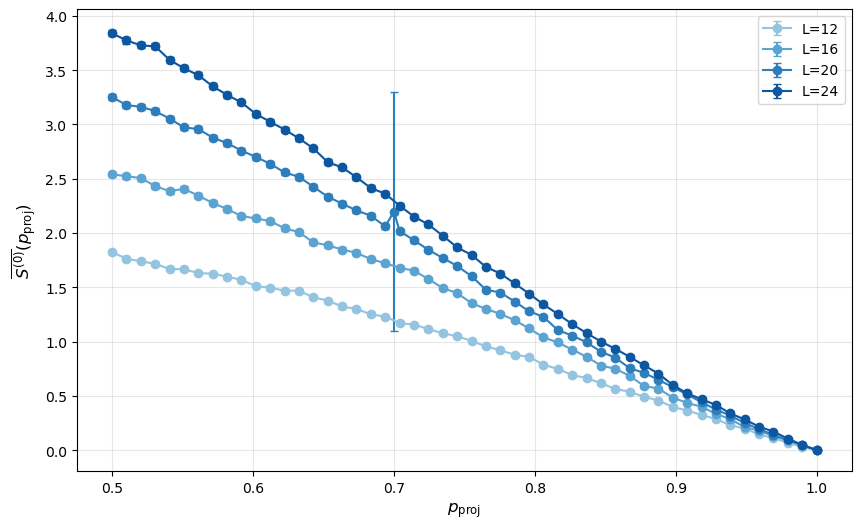

In [37]:
import matplotlib.pyplot as plt
# Plot estimator vs p for different L with same color scheme as data_collapse.py
fig, ax = plt.subplots(figsize=(10, 6))

L_list = df.index.get_level_values('L').unique().sort_values().values
color_iter = iter(plt.cm.Blues(0.4+0.6*(i/L_list.shape[0])) for i in range(L_list.shape[0]))

for L in L_list:
    color = next(color_iter)
    df_L = df.xs(key=L, level='L').sort_index()  # Add sort_index() here
    p_values = df_L.index.get_level_values('p').values
    estimator_values = df_L['estimator'].values
    stderr_values = df_L['standard_error'].values
    
    ax.errorbar(p_values, estimator_values, yerr=stderr_values, 
                fmt='o-', color=color, label=f'L={L}', capsize=3, markersize=6)

ax.set_xlabel(r'$p_{\mathrm{proj}}$', fontsize=12)
ax.set_ylabel(r'$\overline{S^{(0)}}(p_{\mathrm{proj}})$', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
# ax.set_ylim()
# plt.tight_layout()
plt.show()

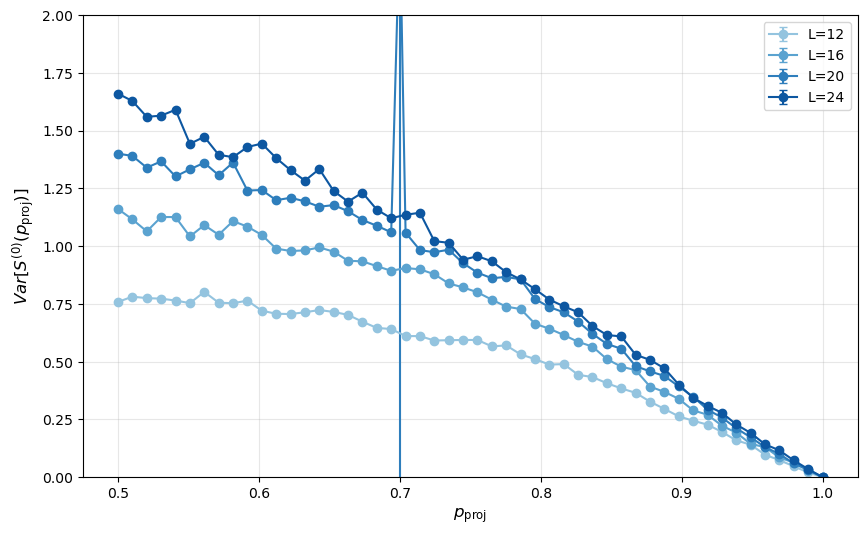

In [43]:
import matplotlib.pyplot as plt
# Plot estimator vs p for different L with same color scheme as data_collapse.py
fig, ax = plt.subplots(figsize=(10, 6))

L_list = df.index.get_level_values('L').unique().sort_values().values
color_iter = iter(plt.cm.Blues(0.4+0.6*(i/L_list.shape[0])) for i in range(L_list.shape[0]))

for L in L_list:
    color = next(color_iter)
    df_L = df.xs(key=L, level='L').sort_index()  # Add sort_index() here
    p_values = df_L.index.get_level_values('p').values
    estimator_values = df_L['variance'].values
    stderr_values = df_L['standard_error_of_variance'].values
    
    ax.errorbar(p_values, estimator_values, yerr=stderr_values, 
                fmt='o-', color=color, label=f'L={L}', capsize=3, markersize=6)

ax.set_xlabel(r'$p_{\mathrm{proj}}$', fontsize=12)
ax.set_ylabel(r'$Var[S^{(0)}(p_{\mathrm{proj}})]$', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 2)
# plt.tight_layout()
plt.show()

In [44]:
df.to_csv('MPS_0.4_cutoff1e-10_threshold1e-14.csv')

In [ ]:
filename = "hdf5_data/p_ctrl0.4_haining/MPS_L24_pctrl0.400_pproj0.531_s403.h5"
with h5py.File(filename, "r") as f:
    sv_arr = f['sv_arr'][:]
    # get the l2 norm of sv_arr
    import numpy as np
    l2_norm = np.linalg.norm(sv_arr)
    print(l2_norm)
    print(f['sv_arr'].attrs.keys())
    print(f['sv_arr'][:])
    print(f['sv_arr'].attrs['L'])
    print(f['sv_arr'].attrs['p_ctrl'])
    print(f['sv_arr'].attrs['p_proj'])
    print(f['sv_arr'].attrs['seed'])
    print(f['sv_arr'].attrs['eps'])

    
